In [1]:
# Shock analysis
# Plotting settings
import mesa
import pandas as pd
from helpers import plot_all_agent_graphs
# Graphs font
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_palette(["#8E44AD", "#C08081", "#f97743", "#2f6edd", "#28b36a", "#333333"])
import matplotlib.ticker as mtick
plt.rcParams['font.family'] = 'Georgia'
color_dict = {
    'Anti - environment': '#f97743',
    'Neutral': '#2f6edd',
    'Pro - environment': '#28b36a'
}
import numpy as np
# Models ------------------------
from model_statusgame import statusgame_model
from one_agent_subclass import OneActiveStatusGameModel



In [ ]:
# Round 1: Identity = 0
np.random.seed(666)

run_p_shock = 50
run_memory = 5
possible_shocks = [0, 0.5, 0.75, 1, 1.25, 1.5]
possible_shocks_dict_identity = {}
    
for s in possible_shocks:
    list_dfs_shock = []
    for i in range(2):
        model_shock_identity = statusgame_model(N=100, seed=666, lambda_s=0, memory=run_memory,
                create_network="watts_strogatz", p=1/100, gamma=1, k=10, rho=1/3, 
                seed_consumption=False, 
                alpha=1/2, 
                weights=[1/3, 1/3, 1/3], 
                shock=s, 
                period_shock=run_p_shock)

        for _ in range(run_p_shock + run_memory + 5):
            model_shock_identity.step()
        # Add df to the list 
        model_shock_identity_df = model_shock_identity.datacollector.get_agent_vars_dataframe().reset_index()
        model_shock_identity_df = model_shock_identity_df.loc[model_shock_identity_df["Step"] >= 40]
        model_shock_identity_df["iteration"] = i 
        list_dfs_shock.append(model_shock_identity_df)

    # Concat
    shock_df = pd.concat(list_dfs_shock)
    shock_df["shock"] = s
    print(s)
    
    # Add to dict
    possible_shocks_dict_identity[s] = shock_df

# Plot
list_final_dfs = []
for k in possible_shocks_dict_identity.keys():
    shock_df = possible_shocks_dict_identity[k] 
    shock_df = shock_df.groupby(["Step", "iteration"])["group"].value_counts(normalize=True).unstack().reset_index().fillna(0)
    shock_df["shock"] = k
    list_final_dfs.append(shock_df)

final_df_identity = pd.concat(list_final_dfs)

# Plot 
fig, ax = plt.subplots(figsize = (6,4))
sns.pointplot(x="Step", y="Pro - environment", hue="shock", data=final_df_identity, join=True, markers="o", scale = 0.5, ax=ax)
categories = ax.get_xticks()
labels = [t.get_text() for t in ax.get_xticklabels()]
if '50' in labels:
    idx = labels.index('50')
    ax.axvline(x=categories[idx], color="red", linestyle="dashed")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel("t")
ax.set_ylabel("Share of pro-environmental agents")
ax.legend(title = "Shock", bbox_to_anchor=(1.01, 1), loc='upper left')

plt.savefig("results/shocks_lambda.pdf", bbox_inches = "tight", dpi=300)

0
0.5
1
1.5


In [ ]:
# Round 2: Gamma = 1/300
np.random.seed(666)

run_p_shock = 50
run_memory = 5
possible_shocks = [0, 0.5, 0.75, 1, 1.25, 1.5]
possible_shocks_dict_gamma = {}
    
for s in possible_shocks:
    list_dfs_shock = []
    for i in range(2):
        model_shock_gamma = statusgame_model(N=100, seed=666, lambda_s=1, memory=run_memory,
                create_network="watts_strogatz", p=1/100, gamma=1/300, k=10, rho=1/3, 
                seed_consumption=False, 
                alpha=1/2, 
                weights=[1/3, 1/3, 1/3], 
                shock=s, 
                period_shock=run_p_shock)

        for _ in range(run_p_shock + run_memory + 5):
            model_shock_gamma.step()
        # Add df to the list 
        model_shock_gamma_df = model_shock_gamma.datacollector.get_agent_vars_dataframe().reset_index()
        model_shock_gamma_df = model_shock_gamma_df.loc[model_shock_gamma_df["Step"] >= 40]
        model_shock_gamma_df["iteration"] = i 
        list_dfs_shock.append(model_shock_gamma_df)

    # Concat
    shock_df = pd.concat(list_dfs_shock)
    shock_df["shock"] = s
    print(s)
    
    # Add to dict
    possible_shocks_dict_gamma[s] = shock_df

# Plot
list_final_dfs = []
for k in possible_shocks_dict_gamma.keys():
    shock_df = possible_shocks_dict_gamma[k] 
    shock_df = shock_df.groupby(["Step", "iteration"])["group"].value_counts(normalize=True).unstack().reset_index().fillna(0)
    shock_df["shock"] = k
    list_final_dfs.append(shock_df)

final_df_gamma = pd.concat(list_final_dfs)

# Plot 
fig, ax = plt.subplots(figsize = (6,4))
sns.pointplot(x="Step", y="Pro - environment", hue="shock", data=final_df_gamma, join=True, markers="o", scale = 0.5, ax=ax)
categories = ax.get_xticks()
labels = [t.get_text() for t in ax.get_xticklabels()]
if '50' in labels:
    idx = labels.index('50')
    ax.axvline(x=categories[idx], color="red", linestyle="dashed")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel("t")
ax.set_ylabel("Share of pro-environmental agents")
ax.legend(title = "Shock", bbox_to_anchor=(1.01, 1), loc='upper left')

plt.savefig("results/shocks_gamma.pdf", bbox_inches = "tight", dpi=300)

In [ ]:
# Round 3: Gamma = 1/300
np.random.seed(666)

run_p_shock = 50
run_memory = 5
possible_shocks = [0, 0.5, 0.75, 1, 1.25, 1.5]
possible_shocks_dict_rules = {}
    
for s in possible_shocks:
    list_dfs_shock = []
    for i in range(2):
        model_shock_rules = statusgame_model(N=100, seed=666, lambda_s=1, memory=run_memory,
                create_network="watts_strogatz", p=1/100, gamma=1, k=10, rho=1, 
                seed_consumption=False, 
                alpha=1/100, 
                weights=[1/3, 1/3, 1/3], 
                shock=s, 
                period_shock=run_p_shock)

        for _ in range(run_p_shock + run_memory + 5):
            model_shock_rules.step()
        # Add df to the list 
        model_shock_rules_df = model_shock_rules.datacollector.get_agent_vars_dataframe().reset_index()
        model_shock_rules_df = model_shock_rules_df.loc[model_shock_rules_df["Step"] >= 40]
        model_shock_rules_df["iteration"] = i 
        list_dfs_shock.append(model_shock_rules_df)

    # Concat
    shock_df = pd.concat(list_dfs_shock)
    shock_df["shock"] = s
    print(s)
    
    # Add to dict
    possible_shocks_dict_rules[s] = shock_df

# Plot
list_final_dfs = []
for k in possible_shocks_dict_rules.keys():
    shock_df = possible_shocks_dict_rules[k] 
    shock_df = shock_df.groupby(["Step", "iteration"])["group"].value_counts(normalize=True).unstack().reset_index().fillna(0)
    shock_df["shock"] = k
    list_final_dfs.append(shock_df)

final_df_rules = pd.concat(list_final_dfs)

# Plot 
fig, ax = plt.subplots(figsize = (6,4))
sns.pointplot(x="Step", y="Pro - environment", hue="shock", data=final_df_rules, join=True, markers="o", scale = 0.5, ax=ax)
categories = ax.get_xticks()
labels = [t.get_text() for t in ax.get_xticklabels()]
if '50' in labels:
    idx = labels.index('50')
    ax.axvline(x=categories[idx], color="red", linestyle="dashed")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel("t")
ax.set_ylabel("Share of pro-environmental agents")
ax.legend(title = "Shock", bbox_to_anchor=(1.01, 1), loc='upper left')

plt.savefig("results/shocks_rules.pdf", bbox_inches = "tight", dpi=300)

In [6]:
# Graph 1: Standard behavior of the model
model_prop_neutral = statusgame_model(N=500, seed=666, lambda_s=1, memory=10,
        create_network="watts_strogatz", p=1/100, gamma=1/2, k=3, rho=1/2, seed_consumption=True, alpha=1/2, weights=[1/3, 1/3, 1/3], wait_gamma=True)

for _ in range(50):
    model_prop_neutral.step()
model_prop_neutral_df = model_prop_neutral.datacollector.get_model_vars_dataframe().reset_index()

KeyboardInterrupt: 

In [5]:
model_prop_neutral_df

,index,dense_degree,connected_components,max_path_length,cluster_coefficient
0,0,2.000000,1,237,0.000000
1,1,5.933333,1,6,0.201786
2,2,13.253333,1,4,0.173625
3,3,26.786667,1,3,0.172805
4,4,52.053333,1,3,0.219778
5,5,94.520000,1,2,0.337933
6,6,154.360000,1,2,0.523245
7,7,219.113333,1,2,0.732509
8,8,267.840000,1,2,0.891813
9,9,290.613333,1,2,0.966272


In [ ]:
# 3) Rho, t and alpha 
np.random.seed(666)

params = {"seed": 666, 
          "alpha": np.linspace(0, 1, 10),
          'lambda_s': 1,
          'N':[500],
          "gamma": 1,
          "create_network": "watts_strogatz", 
          "k": [3], 
          "p": [1/100],
          "rho": np.linspace(0, 1, 10),
          "seed_consumption": False, 
          "memory": [1,5,10], 
          "wait_gamma": True}

results_batch = mesa.batch_run(
    statusgame_model,
    parameters=params,
    iterations=1, # To speed up
    max_steps=50,
    number_processes=None,
    #data_collection_period=100,  # Important, otherwise the datacollector will only collect data of the last time step
    display_progress=True,
)

#Save
net_results_df = pd.DataFrame(results_batch)
net_results_df.to_csv("results_network.csv")

  0%|          | 0/300 [00:00<?, ?it/s]

In [14]:
net_results_df

,RunId,iteration,Step,seed,alpha,lambda_s,N,gamma,create_network,k,...,belief_min,belief_median,belief_max,u_pro,u_anti,u_neutral,status_pro,status_anti,status_neutral,degree
0,4,0,50,666,0.0,1,200,0.1,watts_strogatz,5,...,36.741041,62.258986,128.637265,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3
1,4,0,50,666,0.0,1,200,0.1,watts_strogatz,5,...,46.084122,93.089193,140.094265,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2
2,4,0,50,666,0.0,1,200,0.1,watts_strogatz,5,...,-4.361381,44.441234,109.456961,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2
3,4,0,50,666,0.0,1,200,0.1,watts_strogatz,5,...,-31.921137,59.382307,130.688097,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2
4,4,0,50,666,0.0,1,200,0.1,watts_strogatz,5,...,5.558810,115.758131,123.184331,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179995,899,0,50,666,1.0,1,200,0.1,watts_strogatz,5,...,-47.936755,131.969778,136.976450,0.997487,83.580402,67.163317,0.997487,83.580402,67.163317,201
179996,899,0,50,666,1.0,1,200,0.1,watts_strogatz,5,...,-47.936755,131.942860,136.976450,0.997487,30.349246,22.886935,0.997487,30.349246,22.886935,201
179997,899,0,50,666,1.0,1,200,0.1,watts_strogatz,5,...,-47.936755,131.942860,136.976450,0.997487,51.741206,35.324121,0.997487,51.741206,35.324121,201
179998,899,0,50,666,1.0,1,200,0.1,watts_strogatz,5,...,-47.936755,131.942860,136.976450,0.997487,33.831658,25.374372,0.997487,33.831658,25.374372,201


In [16]:
analysis = net_results_df.loc[net_results_df.memory  == 30]
analysis = analysis.loc[analysis.alpha > 0]

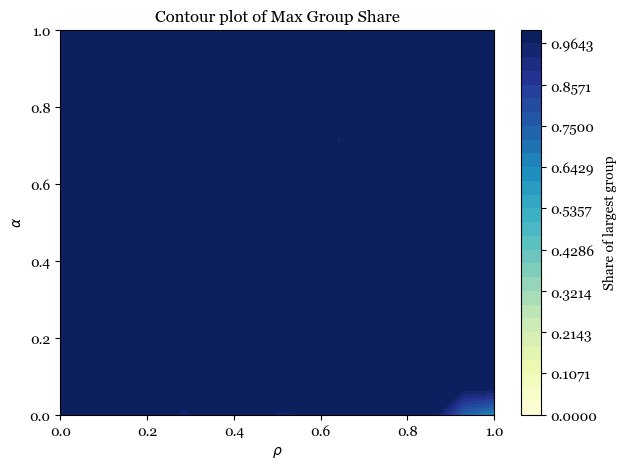

In [12]:
# Refine datasets
grouped = (
    net_results_df.loc[net_results_df.memory  == 15]
    .groupby(["alpha", "rho", "iteration"])["group"]
    .value_counts(normalize=True)   # gives fraction in each group
    .unstack(fill_value=0)          # create separate columns for each group
    .reset_index()
)

group_columns = ["Pro - environment", "Neutral", "Anti - environment"]
grouped["max_share"] = grouped[group_columns].max(axis=1)

# Average across iterations
agg_df = (
    grouped
    .groupby(["alpha", "rho"], as_index=False)["max_share"]
    .mean()
)

# Sort alpha and rho so meshgrid is created in ascending order
alpha_vals = np.sort(agg_df["alpha"].unique())
rho_vals   = np.sort(agg_df["rho"].unique())

# Create meshgrid (X, Y)
A, R = np.meshgrid(alpha_vals, rho_vals)

# Pivot your aggregated DataFrame to get Z
pivoted = agg_df.pivot(index="rho", columns="alpha", values="max_share")
Z = pivoted.reindex(index=rho_vals, columns=alpha_vals).values


# Plot ------------------

fig, ax = plt.subplots(figsize=(7,5))

# Filled contour
levels = np.linspace(0, 1, 29)
cs = ax.contourf(R, A, Z, levels = levels, cmap="YlGnBu")

# Add colorbar (especially if using contourf)
fig.colorbar(cs, ax=ax, label="Share of largest group")

ax.set_ylabel(r"$\alpha$")
ax.set_xlabel(r"$\rho$")
ax.set_title("Contour plot of Max Group Share")

plt.show()

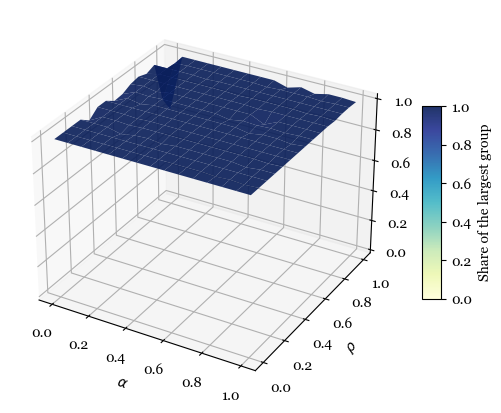

In [13]:
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')

# Option A: surface plot
surf = ax.plot_surface(A, R, Z, cmap="YlGnBu", edgecolor="none", alpha=0.9, vmin=0, vmax=1)

# Option B (alternative): wireframe plot
# ax.plot_wireframe(A, R, Z, color="black", linewidth=0.5)

ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$\rho$")
ax.set_zlabel("")
ax.set_zlim(0, 1.01)

fig.colorbar(surf, shrink=0.5, aspect=10, label="Share of the largest group")
#plt.title("Largest Group Share vs. alpha vs. rho")
plt.show()